In [4]:
import numpy as np
import pandas as pd
from tqdm import tqdm

In [23]:
#REGULAR LS Model using deg 3 polynomials
def generate_paths(S0, r, sigma, T, M, N):
    """
    Simulates underlying asset price paths for each asset with its own time-to-maturity.
        S0    : array of initial asset prices (length L)
    r     : array of risk-free rates (length L)
    sigma : array of volatilities (length L)
    T     : array of times to maturity (length L) or a scalar (in years)
    M     : number of time steps (so M+1 simulation points including time 0)
    N     : number of simulation paths

    Returns:
        paths: a NumPy array of shape (L, M+1, N)
    """
    S0 = np.atleast_1d(S0)
    r = np.atleast_1d(r)
    sigma = np.atleast_1d(sigma)
    T = np.atleast_1d(T)
    L = len(S0)

    # If T was provided as a scalar, broadcast it.
    if T.size == 1:
        T = np.full(L, T[0])

    # dt for each asset (shape: (L,))
    dt = T / M             

    # Reshape dt so it can be broadcast along time and simulation axes.
    dt_bc = dt[:, np.newaxis, np.newaxis]  # shape (L, 1, 1)

    # Generate normal variates for each asset, each time step and each path.
    Z = np.random.randn(L, M, N)

    # Compute log-increments for each asset.
    increments = (r[:, np.newaxis, np.newaxis] - 0.5 * sigma[:, np.newaxis, np.newaxis]**2) * dt_bc \
                + sigma[:, np.newaxis, np.newaxis] * np.sqrt(dt_bc) * Z
                
    # Cumulative sum gives log prices. Prepend zeros so that time0 is S0.
    logS = np.concatenate((np.zeros((L, 1, N)), np.cumsum(increments, axis=1)), axis=1)

    # Compute asset price paths.
    paths = S0[:, np.newaxis, np.newaxis] * np.exp(logS)
    return paths


def backward_induction(paths, K, r, T, M, degree=3):
    """
    Performs backward induction for the Least-Squares Monte Carlo algorithm for each asset individually.
    paths  : array with shape (L, M+1, N)
    K      : array of strike prices (length L) or scalar strike (will be broadcast)
    r      : array of risk-free rates (length L)
    T      : array of times-to-maturity (length L) or scalar (in years)
    M      : number of time steps (without the initial time point)
    degree : degree of polynomial to use in regression.

    Returns:
        prices: a 1D array of prices (one per asset) at time 0.
    """
    K = np.atleast_1d(K)
    r = np.atleast_1d(r)
    T = np.atleast_1d(T)
    L, num_steps, N = paths.shape  # note: num_steps = M+1

    # If K or T are scalar (size=1), broadcast to length L.
    if K.size == 1:
        K = np.full(L, K[0])
    if T.size == 1:
        T = np.full(L, T[0])

    prices = np.zeros(L)
    reg_coeffs = np.zeros((L, M, degree + 1))  # Store regression coefficients for each asset and time step

    for l in range(L): # iterate over each asset (option)
        asset_paths = paths[l, :, :]  # shape (M+1, N) for asset l
        
        # Compute dt specific to asset l.
        dt_l = T[l] / M
        # One-period discount factor for asset l.
        disc = np.exp(-r[l] * dt_l)
        
        # Cash flows at maturity for asset l.
        cashflow = np.maximum(K[l] - asset_paths[-1, :], 0)
        optimal_exercise_time = np.full(N, M)  # Initialize with M (last time step)
        
        # Backward induction from t=M-1 down to t=1.
        for t in range(M-1, 0, -1):
            # Immediate exercise payoff at time t.
            immediate = np.maximum(K[l] - asset_paths[t, :], 0)

            # Identify in-the-money paths.
            itm = immediate > 0
            if np.any(itm):
                X = asset_paths[t, :][itm]  # underlying asset prices (for ITM paths)
                Y = cashflow[itm] * disc
                if len(X) > degree:
                    poly = np.polyfit(X, Y, degree)
                    cont_estimate = np.polyval(poly, cashflow)
                else:
                    cont_estimate = np.zeros_like(X)

                # Determine if early exercise is optimal.
                exercise = immediate[itm] > cont_estimate[itm]
                indices = np.arange(N)[itm]
                # indices = np.where(itm)[0]
                cashflow[indices[exercise]] = immediate[indices[exercise]]
                optimal_exercise_time[indices[exercise]] = t  # Store the optimal exercise time

            # Discount cashflow one period backward.
            cashflow = disc * cashflow
            reg_coeffs[l, t] = poly  # Store regression coefficients for asset l at time t
        
        # Finally, discount from time point 1 to 0.
        price_asset = np.mean(cashflow)
        prices[l] = price_asset
        
    return prices, reg_coeffs

def american_put_lsm(S0, K, r, sigma, T, M=50, N=100000, degree=3):
    S0 = np.atleast_1d(S0)
    K = np.atleast_1d(K)
    r = np.atleast_1d(r)
    sigma = np.atleast_1d(sigma)
    T = np.atleast_1d(T)

    # Broadcast scalar inputs to match number of assets if necessary.
    L = len(S0)
    if K.size == 1:
        K = np.full(L, K[0])
    if T.size == 1:
        T = np.full(L, T[0])

    paths = generate_paths(S0, r, sigma, T, M, N)
    return backward_induction(paths, K, r, T, M, degree)

# Example Usage
S0 = np.array([36] * 4 + [40] * 4 + [44] * 4)  # Initial stock price for a single asset
K = [40] * 12   # Strike price
r = np.array([0.06] * 12)  # Risk-free rate (annualized)
sigma = np.array([0.2, 0.2, 0.4, 0.4] * 3)  # Volatility (annualized)
T = [1, 2] * 6  # Time to maturity (in years)
M = 50  # Number of time steps
N = 2**16  # Number of simulated paths
degree = 3  # Polynomial degree for regression
prices, reg_coeffs = american_put_lsm(S0, K, r, sigma, T, M, N, degree)
print(f"LSM American Put Prices: ", prices)
print(f"shape:{reg_coeffs.shape}")
# total = np.full(12, 0, dtype=float)
# for i in range(10):
#     total += american_put_lsm(S0, K, r, sigma, T, M, N, degree)
# print(f"Average Price: ", total / 10)

LSM American Put Prices:  [3.95775538 4.03358192 6.47788136 7.14326217 0.84220804 1.71821903
 5.24152173 6.0236126  0.64094092 1.09638058 2.97666984 4.24604899]
shape:(12, 50, 4)


In [2]:
def generate_paths(S0, r, sigma, T, M, N):
    """
    Simulates underlying asset price paths for each asset with its own time-to-maturity.
        S0    : array of initial asset prices (length L)
    r     : array of risk-free rates (length L)
    sigma : array of volatilities (length L)
    T     : array of times to maturity (length L) or a scalar (in years)
    M     : number of time steps (so M+1 simulation points including time 0)
    N     : number of simulation paths

    Returns:
        paths: a NumPy array of shape (L, M+1, N)
    """
    S0 = np.atleast_1d(S0)
    r = np.atleast_1d(r)
    sigma = np.atleast_1d(sigma)
    T = np.atleast_1d(T)
    L = len(S0)

    # If T was provided as a scalar, broadcast it.
    if T.size == 1:
        T = np.full(L, T[0])

    # dt for each asset (shape: (L,))
    dt = T / M             

    # Reshape dt so it can be broadcast along time and simulation axes.
    dt_bc = dt[:, np.newaxis, np.newaxis]  # shape (L, 1, 1)

    # Generate normal variates for each asset, each time step and each path.
    Z = np.random.randn(L, M, N)

    # Compute log-increments for each asset.
    increments = (r[:, np.newaxis, np.newaxis] - 0.5 * sigma[:, np.newaxis, np.newaxis]**2) * dt_bc \
                + sigma[:, np.newaxis, np.newaxis] * np.sqrt(dt_bc) * Z
                
    # Cumulative sum gives log prices. Prepend zeros so that time0 is S0.
    logS = np.concatenate((np.zeros((L, 1, N)), np.cumsum(increments, axis=1)), axis=1)

    # Compute asset price paths.
    paths = S0[:, np.newaxis, np.newaxis] * np.exp(logS)
    return paths

def compute_delta_regularized_beta(S_ex, S_ti, t_ex, K, r, t_index, dt, degree=3):
    """
    Computes the regularized regression coefficients using the formula:
    beta = inv(Phi^T Phi + lambda_reg*(Phi_prime^T Phi_prime))
            * [ Phi^T (e^(-r*t_i) * h(S_ex)) + lambda_reg*(Phi_prime^T Z_s) ]

    where:
    • S_ex is the optimal exercise asset price (S₍tᵢ*₎) for the ITM paths.
    • S_ti is the asset price at the current timestep t_i.
    • h(S_ex) is the intrinsic put payoff = max(K - S_ex, 0).
    • The discount factor is computed as exp(-r*(t_index*dt)); here t_index represents t_i.
    • Z_s is defined as: Z_s = - S_ex / S_ti.
    • Phi is the design matrix based on a polynomial basis up to degree 3: [1, S_ex, S_ex², S_ex³].
    • Phi_prime is its derivative: [0, 1, 2S_ex, 3S_ex²].
    • lambda_reg is defined as (|| - e^(-r*t_i)*h(S_ex) ||²)/(||Z_s||²).

    Inputs:
    S_ex    : numpy array, asset prices at the optimal exercise date (S₍tᵢ*₎) for ITM paths.
    S_ti    : numpy array, asset prices at the current timestep t_i.
    K       : strike price (scalar).
    r       : risk-free rate (scalar).
    t_index : current timestep index (representing t_i).

    Returns:
    beta    : numpy array of regression coefficients (with 4 elements).
    """
    import numpy as np

    # Compute discount factor using the difference between exercise time and t_index.
    # Here we assume t_ex is an array (or scalar) of exercise times.
    discount_target = np.exp(-r * dt * (t_ex - t_index))

    # Calculate the intrinsic put payoff (h(S_ex) = max(K - S_ex, 0))
    h_S = np.maximum(K - S_ex, 0)
    target = discount_target * h_S

    # Build the design matrix Phi for polynomial basis [1, S_ex, S_ex^2, ..., S_ex^(degree)]
    Phi = np.column_stack([S_ex**i for i in range(degree+1)])

    # Build the derivative matrix Phi_prime.
    # The derivative of  S_ex^i is i*S_ex^(i-1); the derivative of the constant term (i=0) is zero.
    Phi_prime = np.column_stack([np.zeros_like(S_ex)] + [i * S_ex**(i-1) for i in range(1, degree+1)])

    # Compute Z_s using the current timestep price S_ti.
    Z_s = - S_ex / (S_ti + 1e-12)  # Adding epsilon to avoid division by zero.

    # Compute lambda_reg as the ratio of squared norms.
    numerator = np.sum(( -target )**2)
    denominator = np.sum(Z_s**2)
    lambda_reg = numerator / (denominator + 1e-12)

    # Form the regularized normal equations.
    A = Phi.T @ Phi + lambda_reg * (Phi_prime.T @ Phi_prime)
    b_vec = Phi.T @ target + lambda_reg * (Phi_prime.T @ Z_s)
    try:
        beta = np.linalg.solve(A, b_vec)
    except np.linalg.LinAlgError:
        beta = np.linalg.lstsq(A, b_vec, rcond=None)[0]
        
    return beta


def backward_induction(paths, K, r, T, M, degree=3):
    """
    Performs backward induction for the Least-Squares Monte Carlo algorithm for each asset individually.
    paths  : array with shape (L, M+1, N)
    K      : array of strike prices (length L) or scalar strike (will be broadcast)
    r      : array of risk-free rates (length L)
    T      : array of times-to-maturity (length L) or scalar (in years)
    M      : number of time steps (without the initial time point)
    degree : degree of polynomial to use in regression.

    Returns:
        prices: a 1D array of prices (one per asset) at time 0.
    """
    K = np.atleast_1d(K)
    r = np.atleast_1d(r)
    T = np.atleast_1d(T)
    L, num_steps, N = paths.shape  # note: num_steps = M+1

    # If K or T are scalar (size=1), broadcast to length L.
    if K.size == 1:
        K = np.full(L, K[0])
    if T.size == 1:
        T = np.full(L, T[0])

    prices = np.zeros(L)
    reg_coeffs = np.zeros((L, M, degree + 1))  # Store regression coefficients for each asset and time step

    for l in range(L): # iterate over each asset (option)
        asset_paths = paths[l, :, :]  # shape (M+1, N) for asset l
        
        # Compute dt specific to asset l.
        dt_l = T[l] / M
        # One-period discount factor for asset l.
        disc = np.exp(-r[l] * dt_l)
        
        # Cash flows at maturity for asset l.
        cashflow = np.maximum(K[l] - asset_paths[-1, :], 0)
        optimal_exercise_time = np.full(N, M)  # Initialize with M (last time step)
        
        # Backward induction from t=M-1 down to t=1.
        for t in range(M-1, 0, -1):
            # Immediate exercise payoff at time t.
            immediate = np.maximum(K[l] - asset_paths[t, :], 0)
            S_ex = asset_paths[optimal_exercise_time, np.arange(N)]
            S_ti = asset_paths[t, np.arange(N)]
            beta = compute_delta_regularized_beta(S_ex, S_ti, optimal_exercise_time, K[l], r[l], t, dt_l, degree)
            poly = np.poly1d(beta[::-1])  # Reverse the order of coefficients for np.polyval

            # Identify in-the-money paths.
            itm = immediate > 0
            if np.any(itm):
                X = asset_paths[t, :][itm]  # underlying asset prices (for ITM paths)
                if len(X) > degree:
                    # poly = np.polyfit(X, Y, degree)
                    cont_estimate = np.polyval(poly, X)
                else:
                    cont_estimate = np.zeros_like(X)

                # Determine if early exercise is optimal.
                exercise = immediate[itm] > cont_estimate
                indices = np.arange(N)[itm]
                # indices = np.where(itm)[0]
                cashflow[indices[exercise]] = immediate[indices[exercise]]
                optimal_exercise_time[indices[exercise]] = t  # Store the optimal exercise time

            # Discount cashflow one period backward.
            cashflow = disc * cashflow
            reg_coeffs[l, t] = beta  # Store regression coefficients for asset l at time t
        
        # Finally, discount from time point 1 to 0.
        price_asset = np.mean(cashflow)
        prices[l] = price_asset
        
    return prices, reg_coeffs

def american_put_lsm(S0, K, r, sigma, T, M=50, N=100000, degree=3):
    S0 = np.atleast_1d(S0)
    K = np.atleast_1d(K)
    r = np.atleast_1d(r)
    sigma = np.atleast_1d(sigma)
    T = np.atleast_1d(T)

    # Broadcast scalar inputs to match number of assets if necessary.
    L = len(S0)
    if K.size == 1:
        K = np.full(L, K[0])
    if T.size == 1:
        T = np.full(L, T[0])

    paths = generate_paths(S0, r, sigma, T, M, N)
    return backward_induction(paths, K, r, T, M, degree)

# Example Usage
S0 = np.array([36] * 4 + [40] * 4 + [44] * 4)  # Initial stock price for a single asset
K = [40] * 12   # Strike price
r = np.array([0.06] * 12)  # Risk-free rate (annualized)
sigma = np.array([0.2, 0.2, 0.4, 0.4] * 3)  # Volatility (annualized)
T = [1, 2] * 6  # Time to maturity (in years)
M = 50  # Number of time steps
N = 2**16  # Number of simulated paths
degree = 3  # Polynomial degree for regression
prices, reg_coeffs = american_put_lsm(S0, K, r, sigma, T, M, N, degree)
print(f"LSM American Put Prices: ", prices)
print(f"shape:{reg_coeffs.shape}")
# total = np.full(12, 0, dtype=float)
# for i in range(10):
#     total += american_put_lsm(S0, K, r, sigma, T, M, N, degree)
# print(f"Average Price: ", total / 10)

LSM American Put Prices:  [4.02364743 4.44842094 6.96563338 8.29630396 2.26141814 2.78307198
 5.18847294 6.78831238 1.08075078 1.65001104 3.87882538 5.50450641]
shape:(12, 50, 4)


In [ ]:
from concurrent.futures import ProcessPoolExecutor
import numpy as np
from functools import partial

def compute_nested_value(nested_paths, betas, K, r, T, M, t):
    """
    Compute nested simulation values for a single outer path
    """
    dt = T / M
    hv_nested = np.maximum(K - nested_paths, 0)
    nested_itm = hv_nested > 0
    
    # Compute continuation values for nested paths
    cv_nested = np.zeros_like(nested_paths)
    for ti in range(nested_paths.shape[0]):
        valid_paths = np.where(nested_itm[ti], nested_paths[ti], np.nan)
        cv_nested[ti] = np.polyval(betas[t+ti], valid_paths)
    
    # Find optimal exercise times
    exercise_signal = hv_nested > cv_nested
    t_hat = np.argmax(exercise_signal, axis=0)
    t_hat = np.where(np.any(exercise_signal, axis=0), t_hat, len(cv_nested) - 1)
    
    # Get payoffs at optimal exercise times
    hv_hat = np.array([hv_nested[t_hat[i], i] for i in range(nested_paths.shape[1])])
    
    # Discount payoffs
    discount = np.exp(-r * dt * (t_hat + t))
    discounted_payoff = hv_hat * discount
    
    return np.mean(discounted_payoff)



def compute_exercise_decision(immediate_value, continuation_value, threshold=1e-10):
    """More robust exercise decision with numerical tolerance"""
    exercise = immediate_value > continuation_value + threshold
    return exercise

def compute_continuation_value(paths, betas, t, K, r, T, M):
    """Separate function for continuation value calculation"""
    itm = paths > 0
    continuation = np.zeros_like(paths)
    
    if np.any(itm):
        poly = np.poly1d(betas[t])
        continuation[itm] = np.polyval(poly, paths[itm])
        # Add boundary conditions
        continuation = np.maximum(continuation, 0)  # Non-negative continuation value
        continuation = np.minimum(continuation, K)  # Upper bound at strike price
    
    return continuation

def compute_upper_bound(hvs, martingales, df):
    """More efficient upper bound computation"""
    N = hvs.shape[0]
    M = hvs.shape[1] - 1
    
    # Vectorized computation of discounted payoffs
    discounted_hvs = hvs * df.reshape(1, -1)
    
    # Compute upper bound process
    upper_bound_process = np.zeros((N, M+1))
    for t in range(M+1):
        upper_bound_process[:, t] = discounted_hvs[:, t] - martingales[:, t]
    
    # Take minimum over stopping times
    upper_bound = np.min(upper_bound_process, axis=1)
    
    return np.mean(upper_bound)

In [ ]:
%pip install numba

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   -- ------------------------------------- 0.2/2.8 MB 1.8 MB/s eta 0:00:02
   --------------- ------------------------ 1.1/2.8 MB 8.4 MB/s eta 0:00:01
   -------------------------------- ------- 2.3/2.8 MB 13.5 MB/s eta 0:00:01
   ---------------------------------------  2.8/2.8 MB 13.9 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 12.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/30.3 MB ? eta -:--:--
   - -------------------------------------- 1.1/30.3 MB 35.0 MB/s eta 0:00:01
   --- ------------------------------------ 2.5/30.3 MB 26.8 MB/s eta 0:00:02
   ---- ----------------------------------- 3.4/30.3 MB 27.4 MB/s eta 0:00:01
   ------ --------------------------------- 4.8/30.3 MB 27.6 MB/s eta 0:00:01
   ------- -------------------------------- 6.0/30.3 MB 27.4 MB/s eta 0:00:01
   --------- ------


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from functools import lru_cache

def compute_upper_bound(hvs, martingales):
    """More efficient upper bound computation"""
    N = hvs.shape[0]
    M = hvs.shape[1] - 1
    
    # Vectorized computation of discounted payoffs
    discounted_hvs = hvs
    
    # Compute upper bound process
    upper_bound_process = discounted_hvs - martingales
    
    # Take minimum over stopping times
    upper_bound = np.max(upper_bound_process, axis=1)
    
    return np.mean(upper_bound)

def discount_factor(r, T, M, curr_time):
    """
    Computes the discount factor for a given risk-free rate and time to maturity.
    r : array of risk-free rates (length L)
    T : array of times to maturity (length L) or scalar (in years)
    M : number of time steps (without the initial time point)
    """
    dt = T / M  # Time increment for each step
    return np.exp(-r * dt * curr_time)  # Discount factor for each step

def dual_pricing(S0, K, r, sigma, T, M, N_outer, N_inner, betas):
    """
    Computes the dual prices for American options using the LSM method.
    S0      : array of initial asset prices (length L)
    K       : array of strike prices (length L) or scalar (will be broadcast)
    r       : array of risk-free rates (length L)
    sigma   : array of volatilities (length L)
    T       : array of times to maturity (length L) or scalar (in years)
    M       : number of time steps (without the initial time point)
    N_outer : number of outer simulation paths
    N_inner : number of inner simulation paths
    betas   : regression coefficients from the backward induction step with shape (L, M, degree+1)
    """
    outer_paths = generate_paths(S0, r, sigma, T, M, N_outer)
    L, _, _ = outer_paths.shape
    upper_bounds = np.zeros((L, M + 1))
    betas = betas[:, :, ::-1]  # Reverse the order of coefficients for np.polyval

    for l in range(L):
        curr_paths = outer_paths[l]
        Vti = np.zeros((N_outer))
        martingales = np.zeros((N_outer, M + 1))
        hvs = np.zeros((N_outer, M + 1))
        hvs[0] = np.maximum(K[l] - curr_paths[:, 0], 0)
        for t in range(1, M + 1):
            df = discount_factor(r[l], T[l], M, t)
            hv = np.maximum(K[l] - curr_paths[t], 0)
            if(t == M):
                martingales[:, t] = martingales[:, t-1]
                hvs[:, t] = hv * df
                continue
            itm = hv > 0
            cv = np.polyval(betas[l, t - 1], curr_paths[t][itm])
            cv_full = np.zeros_like(hv)
            cv_full[itm] = cv
            exercise = hv > cv_full
            Vti[exercise] = df * hv[exercise]
            nested_paths = generate_paths(curr_paths[t], r[l], sigma[l], T[l], M - t, N_inner)[:, 1:, :] #drop timestep t
            #shape of hv_nested is (N_outer, M-t+1, N_inner),
            # so we have n_inner paths for each outer path from timestep t till end
            hv_nested = np.maximum(K[l] - nested_paths, 0) # shape (N_outer, M-t, N_inner)
            nested_itm = hv_nested > 0

            valid_paths = np.where(nested_itm, nested_paths, np.nan)

            cv_nested = np.zeros((N_outer, M-t, N_inner)) # shape (N_outer, M-t, N_inner)
            # for ti in range(M-t):
            #     cv_nested[:, ti, :] = np.polyval(betas[l, t+ti - 1], valid_paths[:, ti, :])
            cv_nested = np.polynomial.polynomial.polyval(valid_paths, betas[l, t:M, :].T)
            
            t_hat = np.argmax(hv_nested > cv_nested, axis=1)
            t_hat = np.where(np.any(hv_nested > cv_nested, axis=1), t_hat, len(cv_nested[0]) - 1)
            hv_hat = np.array([hv_nested[i, t_hat[i], np.arange(N_inner)] for i in range(hv_nested.shape[0])])
            hv_hat = hv_hat * discount_factor(r[l], T[l], M, t_hat + t)  # Discounted cash flow
            Eq = np.mean(hv_hat, axis=1)
            Vti[~exercise] = Eq[~exercise]
            martingales[:, t] = martingales[:, t - 1] + Vti - Eq
            hvs[:, t] = hv * df
        
        # upper_bounds[l] = compute_upper_bound(hvs, martingales)
        max_martingales = np.zeros((N_outer, M + 1))
        ts = martingales.shape[1]
        prev = hvs[:, ts - 1] - max_martingales[:, ts - 1]
        for i in range(ts):
            ub_val = (hvs[:, ts - i - 1] - martingales[:, ts - i - 1])
            max_martingales[:, ts - i - 1] = np.where(ub_val > prev, ub_val, prev)
            prev = hvs[:, ts - i - 1] - max_martingales[:, ts - i - 1]
        upper_bounds[l] = np.mean(max_martingales, axis=0)
    return upper_bounds[:, upper_bounds.shape[1] - 1]

S0 = np.array([36, 38, 40, 42, 44])  # Initial stock price for a single asset
K = [40] * 5   # Strike price
r = np.array([0.06] * 5)  # Risk-free rate (annualized)
sigma = np.array([0.4] * 5)  # Volatility (annualized)
T = [2] * 5  # Time to maturity (in years)
M = 50  # Number of time steps
N = 2**16  # Number of simulated paths
degree = 3  # Polynomial degree for regression
N_outer = 2**11 # Number of outer simulation paths
N_inner = 200 # Number of inner simulation paths
# prices, betas = american_put_lsm(S0, K, r, sigma, T, M, N, degree)
# upper_bounds = dual_pricing(S0, K, r, sigma, T, M, N_outer, N_inner, betas)


In [17]:
print(f"Lower Bounds: {prices}")
print(f"Upper Bounds: {upper_bounds}")

Lower Bounds: [8.31872543 7.50673051 6.75027336 6.12863811 5.47259263]
Upper Bounds: [14.44706348 13.53231707 12.41304122 11.3784521   9.84294794]


In [ ]:
import numpy as np
from multiprocessing import Pool
from functools import partial

def process_batch(batch_indices, S0, K, r, sigma, T, M, N_outer, N_inner, betas):
    """
    Process a batch of assets for dual pricing
    """
    batch_S0 = S0[batch_indices]
    batch_K = [K[i] for i in batch_indices]
    batch_r = r[batch_indices]
    batch_sigma = sigma[batch_indices]
    batch_T = [T[i] for i in batch_indices]
    batch_betas = betas[batch_indices]
    
    batch_size = len(batch_indices)
    outer_paths = generate_paths(batch_S0, batch_r, batch_sigma, batch_T, M, N_outer)
    upper_bounds = np.zeros((batch_size, M + 1))
    
    for l in range(batch_size):
        curr_paths = outer_paths[l]
        Vti = np.zeros((N_outer))
        martingales = np.zeros((N_outer, M + 1))
        hvs = np.zeros((N_outer, M + 1))
        hvs[:, 0] = np.maximum(batch_K[l] - curr_paths[:, 0], 0)
        
        for t in range(1, M + 1):
            df = discount_factor(batch_r[l], batch_T[l], M, t)
            hv = np.maximum(batch_K[l] - curr_paths[:, t], 0)
            
            if t == M:
                martingales[:, t] = martingales[:, t-1]
                hvs[:, t] = hv * df
                continue
                
            itm = hv > 0
            cv = np.polyval(batch_betas[l, t - 1], curr_paths[:, t][itm])
            cv_full = np.zeros_like(hv)
            cv_full[itm] = cv
            exercise = hv > cv_full
            
            Vti[exercise] = df * hv[exercise]
            nested_paths = generate_paths(curr_paths[:, t], batch_r[l], batch_sigma[l], 
                                       batch_T[l], M - t, N_inner)[:, 1:, :]
            
            hv_nested = np.maximum(batch_K[l] - nested_paths, 0)
            nested_itm = hv_nested > 0
            valid_paths = np.where(nested_itm, nested_paths, np.nan)
            
            cv_nested = np.zeros((N_outer, M-t, N_inner))
            for ti in range(M-t):
                cv_nested[:, ti, :] = np.polyval(batch_betas[l, t+ti - 1], valid_paths[:, ti, :])
            
            t_hat = np.argmax(hv_nested > cv_nested, axis=1)
            t_hat = np.where(np.any(hv_nested > cv_nested, axis=1), t_hat, len(cv_nested[0]) - 1)
            hv_hat = np.array([hv_nested[i, t_hat[i], np.arange(N_inner)] for i in range(hv_nested.shape[0])])
            hv_hat = hv_hat * discount_factor(batch_r[l], batch_T[l], M, t_hat + t)
            
            Eq = np.mean(hv_hat, axis=1)
            Vti[~exercise] = Eq[~exercise]
            martingales[:, t] = martingales[:, t - 1] + Vti - Eq
            hvs[:, t] = hv * df
        
        max_martingales = np.zeros((N_outer, M + 1))
        ts = martingales.shape[1]
        prev = hvs[:, ts - 1] - max_martingales[:, ts - 1]
        
        for i in range(ts):
            ub_val = (hvs[:, ts - i - 1] - martingales[:, ts - i - 1])
            max_martingales[:, ts - i - 1] = np.where(ub_val > prev, ub_val, prev)
            prev = hvs[:, ts - i - 1] - max_martingales[:, ts - i - 1]
            
        upper_bounds[l] = np.mean(max_martingales, axis=0)
    
    return upper_bounds[:, -1]

def parallel_dual_pricing(S0, K, r, sigma, T, M, N_outer, N_inner, betas, batch_size=2, num_processes=4):
    """
    Parallelized version of dual pricing that processes assets in batches
    
    Parameters:
    -----------
    batch_size : int
        Number of assets to process in each batch
    num_processes : int
        Number of parallel processes to use
    """
    L = len(S0)
    batches = [range(i, min(i + batch_size, L)) for i in range(0, L, batch_size)]
    
    process_batch_partial = partial(
        process_batch,
        S0=S0, K=K, r=r, sigma=sigma, T=T, M=M,
        N_outer=N_outer, N_inner=N_inner, betas=betas
    )
    
    with Pool(processes=num_processes) as pool:
        results = pool.map(process_batch_partial, batches)
    
    # Combine results from all batches
    upper_bounds = np.concatenate(results)
    return upper_bounds

# Example usage:
# Initialize your parameters as before
S0 = np.array([36, 38, 40, 42, 44, 44])
K = np.array([40] * 6)
r = np.array([0.06] * 6)
sigma = np.array([0.4] * 6)
T = np.array([2] * 6)
M = 50
N_primal = 2**16
N_outer = 2**11
N_inner = 200
prices, betas = american_put_lsm(S0, K, r, sigma, T, M, N_primal, degree)
# Run the parallelized version
upper_bounds = parallel_dual_pricing(
    S0, K, r, sigma, T, M, N_outer, N_inner, betas,
    batch_size=2, num_processes=4
)

In [64]:
upper_bounds

array([0.0258118 , 0.0105213 , 0.00325633, 0.00085664, 0.00011321])

In [30]:
betas = [[1, 2, 3],
         [4, 5, 6], 
         [7, 8, 9], 
         [10, 11, 12]]
nested_paths = [[
    [100, 200, 300, 150],
    [110, 150, 125, 230],
],
[
    [115, 225, 335, 112],
    [123, 343, 134, 122]
],
[
    [115, 225, 335, 112],
    [123, 343, 134, 122]
],
[
    [115, 225, 335, 112],
    [123, 343, 134, 122]
]]
betas = np.array(betas)
nested_paths = np.array(nested_paths)
cv_nested = np.zeros((4, 2)) # shape (N_outer, M-t)
hv_nested = np.maximum(200 - nested_paths, 0) # shape (N_outer, M-t, N_inner)
nested_itm = hv_nested > 0
valid_paths = np.where(nested_itm, nested_paths, np.nan)
cv_values = np.polynomial.polynomial.polyval(betas[1:4], valid_paths)

In [ ]:
def generate_paths(S0, r, sigma, T, M, N):
    dt = T / M
    Z = np.random.randn(M, N)  # Normal random variables
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(increments, axis=0)
    paths = S0 * np.exp(log_paths)
    paths = np.vstack([np.full(N, S0), paths])  # Add initial stock price
    return paths

def backward_induction(paths, K, r, T, M, degree=2):
    dt = T / M
    discount = np.exp(-r * dt)
    cashflows = np.maximum(K - paths[-1], 0)  # Final payoffs at maturity

    for t in range(M - 1, 0, -1):  # Work backwards
        in_the_money = np.where(paths[t] < K)[0]  # Find ITM paths
        if len(in_the_money) == 0:
            continue

        X = paths[t, in_the_money]  # Stock prices at time t
        Y = cashflows[in_the_money] * discount  # Discounted future payoffs

        # Polynomial regression for continuation value
        poly = np.polyfit(X, Y, degree)
        continuation_value = np.polyval(poly, X)

        # Early exercise decision
        exercise_value = K - X
        exercise = exercise_value > continuation_value
        cashflows[in_the_money[exercise]] = exercise_value[exercise]

    return np.mean(cashflows) * discount  # Discount to present value

def american_put_lsm(S0, K, r, sigma, T, M=50, N=100000, degree=2):
    paths = generate_paths(S0, r, sigma, T, M, N)
    return backward_induction(paths, K, r, T, M, degree)

# Example Usage
S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1
price = american_put_lsm(S0, K, r, sigma, T)
print(f"LSM American Put Price: {price:.4f}")


In [101]:
import numpy as np

def generate_mc_paths(S_t, r, sigma, T, N, M, t):
    """
    Generate Monte Carlo paths for Geometric Brownian Motion (GBM),
    starting from timestep t+1 to M.

    Parameters:
        S_t (float): Asset price at time t.
        r (float): Risk-free rate.
        sigma (float): Volatility.
        T (float): Total time (in years).
        N (int): Number of paths.
        M (int): Total timesteps.
        t (int): Current timestep.

    Returns:
        np.ndarray: Simulated asset paths of shape (N, M-t).
    """
    dt = T / M  # Time step size
    num_timesteps = M - t  # From t+1 to M

    # Generate standard normal random numbers
    Z = np.random.normal(size=(N, num_timesteps))

    # Compute drift and diffusion components
    drift = (r - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt) * Z

    # Initialize paths
    paths = np.zeros((N, num_timesteps))
    paths[:, 0] = S_t * np.exp(drift + diffusion[:, 0])  # First step evolution


    # Simulate log returns and exponentiate
    for i in range(1, num_timesteps):
        paths[:, i] = paths[:, i-1] * np.exp(drift + diffusion[:, i-1])

    return paths

# Example usage
S_t, r, sigma, T = 100, 0.05, 0.2, 1  # Price at t, rate, volatility, total time
N, M, t = 1000, 10, 2  # 1000 paths, 10 timesteps, starting at t=2

mc_paths = generate_mc_paths(S_t, r, sigma, T, N, M, t)
print(mc_paths.shape)  # Expected output: (1000, 8)

(1000, 8)


In [105]:
import numpy as np
from scipy.stats import norm
from scipy import stats
from scipy.optimize import fminbound
from scipy.stats import norm
from scipy.stats import qmc


def simulate_paths(S0, r, sigma, T, n_steps, n_paths, use_sobol=True, scramble=True, seed=123):
    # Time step size
    dt = T / n_steps
    
    if use_sobol:
        # Use SciPy’s Sobol generator in [0, 1]^n_steps; then transform via the inverse normal
        sampler = qmc.Sobol(d=n_steps, scramble=scramble, seed=seed)
        u = sampler.random(n_paths)
        # Convert uniform to standard normal using inverse CDF
        z = norm.ppf(u)
    else:
        # Use standard normal random variables if Sobol is not chosen
        z = np.random.randn(n_paths, n_steps)
    
    # Pre-compute drift and diffusion factors
    drift = (r - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt)
    
    # Simulate returns and then cumulative sum for log-price
    increments = drift + diffusion * z
    logS = np.log(S0) + np.cumsum(increments, axis=1)
    
    # Compute actual prices by exponentiating the log-prices
    S = np.exp(logS)
    
    # Insert S0 at time 0 as the first column
    S = np.concatenate([np.full((n_paths, 1), S0), S], axis=1)
    
    return S

In [ ]:
def american_put_dual(S0, K, r, sigma, T, M=50, N_outer=10000, N_nested=200, degree=3):
    """
    Using the nested simulation dual approach we compute an upper bound
    for a set (L) of American put options."
    Procedure for each asset (l = 1,...,L):
    1. Generate N_outer outer simulation paths (from time 0 to T).
    2. Use a backward induction (LSM style) to compute the exercise time for each outer path.
    3. For each outer simulation path:
        • Initialize martingale = 0.
        • For each time t in {0,1,...,M} compute candidate dual value:
                    candidate = D(0,t) * h(S_t) - M_t.
        • At each time step t (if t < M) update the martingale:
                Let V_next be the one–step continuation value.
                Here we approximate V_next by (a) if the LSM exercise rule indicates exercise at t+1,
                then set V_next = h(S[t+1]);
                else we run two independent nested simulations (from the state S[t+1])
                over the remaining time to maturity and set
                    mart_inc = (avg(nested sample #1) - avg(nested sample #2)).
                Then update M_{t+1} = M_t + mart_inc.
        • The dual estimate on the outer path is the maximum over t of the candidates.
    4. Average the dual estimates over outer simulation paths.
    
    Returns:
    dual_prices: an array of length L containing the dual (upper bound) price for each asset.

    Note: This is a simplified version. In practice one would use more careful conditioning,
        independent nested simulations etc.
    """
    S0 = np.atleast_1d(S0)
    K  = np.atleast_1d(K)
    r  = np.atleast_1d(r)
    sigma = np.atleast_1d(sigma)
    T = np.atleast_1d(T)
    L = len(S0)
    dt = T / M  # time step size for each asset
    dual_prices = np.zeros(L)
    outer_paths = generate_paths(S0, r, sigma, T, M, N_outer)
    _, all_exercise_times, path_prices = backward_induction(outer_paths, K, r, T, M, degree)

    for l in range(L):
        exercise_times = all_exercise_times[l]
        curr_paths = path_prices[l]
        S = simulate_paths(S0[l], r[l], sigma[l], T[l], M, N_outer, use_sobol=True, scramble=True)
        martingales = np.zeros(N_outer)
        for path in range(N_outer):
            curr_martingale = 0
            max_martingale = 0
            curr_path = curr_paths[:, path]
            D_m = 0
            for t in range(M + 1):
                if t == M:
                    V_ti = 0
                    EQ_ti = 0
                    if exercise_times[t, path] == t:
                        V_ti = (K[l] - curr_path[t]) * np.exp(-r[l] * t * dt[l]) # discounted payoff from exercise
                    curr_martingale += curr_martingale + V_ti - EQ_ti
                    D_m = np.exp(-r[l] * dt[l] * t)
                    h_Sku = max(0, K[l] - curr_path[t])
                    mc = D_m * h_Sku - curr_martingale
                    if mc > max_martingale:
                        max_martingale = mc
                    continue
                nested_paths = generate_mc_paths(curr_path[t], r[l], sigma[l], T[l], N_nested, M, t)
                t_hat = np.argmax(nested_paths < K[l], axis=1) + (nested_paths >= K[l]).all(axis=1) * (M - t - 1)
                h_that = nested_paths[:, t_hat]
                D_t = np.exp(-r[l] * dt[l] * (t_hat + t))  # discount factor
                EQ_ti = np.mean(h_that * D_t) # expected value of the discounted payoff
                V_ti = EQ_ti
                if exercise_times[t, path] == t:
                    # do part 2(b) from Andersen and Broadie (2004)
                    V_ti = (K[l] - curr_path[t]) * np.exp(-r[l] * t * dt[l]) # discounted payoff from exercise
                curr_martingale += V_ti - EQ_ti
                D_m = np.exp(-r[l] * dt[l] * t)
                h_Sku = max(0, K[l] - curr_path[t])
                mc = D_m * h_Sku - curr_martingale
                if mc > max_martingale:
                    max_martingale = mc
            martingales[path] = max_martingale
        dual_prices[l] = np.mean(martingales)
    return dual_prices
# We first compute the primal LSM prices.
# (These serve as lower bounds.)
S0 = np.array([100, 200]) # initial asset prices (L=2)
K = np.array([100, 190]) # strike prices
r = np.array([0.05, 0.05]) # risk-free rates
sigma = np.array([0.2, 0.2]) # volatilities
T = np.array([1, 0.5]) # times-to-maturity (years)
M = 50 # number of time steps
N_primal = 2**13 # number of simulated paths for primal LSM
degree = 3 # polynomial degree
N_outer = 2000   # number of outer simulation paths (for dual)
N_nested = 200   # number of nested simulation paths
dual_prices = american_put_dual(S0, K, r, sigma, T, M, N_outer, N_nested, degree)
print("Dual Upper Bound American Put Prices:", dual_prices)

Dual Upper Bound American Put Prices: [100. 190.]


In [3]:
df = pd.read_parquet("data/2024_XIU.parquet")

In [5]:
from openbb import obb
from datetime import datetime, timedelta
import math
symbol = "XIU"  #This symbol is not always the same as the stock symbol

options_day = datetime.strptime("2024-12-31", "%Y-%m-%d")

obb.user.preferences.output_type = "dataframe"
price_df = obb.equity.price.historical("XIU", start_date=options_day - timedelta(days=355), end_date=options_day, interval="1d", provider="tmx")
annualized_volatility = price_df["change_percent"].std() * math.sqrt(250) #250 canadian trading days

In [6]:
df["T"] = df["dte"] / 365
df["sigma"] = annualized_volatility
df["r"] = 0.05  # Assuming a constant risk-free rate of 5%
df["S0"] = df["underlying_price"]
df["K"] = df["strike"]

In [18]:
puts = df[df["option_type"] == "put"]
puts_monthly = puts[(puts["dte"] >= 30) & (puts["dte"] <= 60)]
puts_monthly

,expiration,strike,option_type,underlying_symbol,underlying_price,contract_symbol,eod_date,dte,open_interest,volume,...,implied_volatility,transactions,total_value,settlement_price,Breakeven,T,sigma,r,S0,K
query_date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,2024-02-02,30.00,put,XIU:CA,31.93,XIU 240202P30.00,2024-01-02,31,0,0,...,0.16414,0,0.0,0.10,29.90,0.084932,0.10163,0.05,31.93,30.00
2024-01-01,2024-02-02,30.25,put,XIU:CA,31.93,XIU 240202P30.25,2024-01-02,31,0,0,...,0.15179,0,0.0,0.11,30.14,0.084932,0.10163,0.05,31.93,30.25
2024-01-01,2024-02-02,30.50,put,XIU:CA,31.93,XIU 240202P30.50,2024-01-02,31,0,0,...,0.14443,0,0.0,0.13,30.37,0.084932,0.10163,0.05,31.93,30.50
2024-01-01,2024-02-02,30.75,put,XIU:CA,31.93,XIU 240202P30.75,2024-01-02,31,0,0,...,0.13242,0,0.0,0.15,30.60,0.084932,0.10163,0.05,31.93,30.75
2024-01-01,2024-02-02,31.00,put,XIU:CA,31.93,XIU 240202P31.00,2024-01-02,31,0,0,...,0.12755,0,0.0,0.18,30.82,0.084932,0.10163,0.05,31.93,31.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-18,2025-04-17,41.00,put,XIU:CA,39.13,XIU 250417P41.00,2025-02-18,58,2,0,...,0.14333,0,0.0,2.21,38.79,0.158904,0.10163,0.05,39.13,41.00
2025-02-18,2025-04-17,41.25,put,XIU:CA,39.13,XIU 250417P41.25,2025-02-18,58,0,0,...,0.15315,0,0.0,2.46,38.79,0.158904,0.10163,0.05,39.13,41.25
2025-02-18,2025-04-17,41.50,put,XIU:CA,39.13,XIU 250417P41.50,2025-02-18,58,2,0,...,0.16379,0,0.0,2.71,38.79,0.158904,0.10163,0.05,39.13,41.50


In [9]:
def american_put_lsm_batched(S0, K, r, sigma, T, M=50,
N=10000, batch_size=10000, degree=2):
    S0 = np.atleast_1d(S0)
    L = len(S0)

    # Ensure inputs K and T are arrays of length L.
    K = np.atleast_1d(K)
    T = np.atleast_1d(T)
    if K.size == 1:
        K = np.full(L, K[0])
    if T.size == 1:
        T = np.full(L, T[0])

    n_batches = math.ceil(len(S0) / batch_size)
    results = np.array([])
    for i in tqdm(range(n_batches), desc="Batched LSM"):
        current_batch_size = batch_size if (i*batch_size + batch_size <= len(S0)) else (len(S0) - i*batch_size)
        start_index = i * batch_size
        end_index = start_index + current_batch_size
        # Generate paths for this batch.
        paths = generate_paths(S0[start_index:end_index], r[start_index:end_index], sigma[start_index:end_index], T[start_index:end_index], M, N)

        prices_batch = backward_induction(paths, K[start_index:end_index], r[start_index:end_index], T[start_index:end_index], M, degree)
        results = np.concatenate((results, prices_batch))

    return results

In [ ]:
M = 50                            # Number of time steps.
N = 1000                         # Total number of simulation paths desired.
batch_size = 1000                  # Number of paths per batch.
degree = 3                        # Degree of polynomial regression.
puts_monthly["model_price"] = american_put_lsm_batched(puts_monthly["S0"].values, puts_monthly["K"].values, puts_monthly["r"].values, puts_monthly["sigma"].values, puts_monthly["T"].values, M, N, batch_size, degree)

Batched LSM: 100%|██████████| 32/32 [06:26<00:00, 12.07s/it]
C:\Users\viraj\AppData\Local\Temp\ipykernel_25460\2952280868.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puts_monthly["model_price"] = american_put_lsm_batched(puts_monthly["S0"].values, puts_monthly["K"].values, puts_monthly["r"].values, puts_monthly["sigma"].values, puts_monthly["T"].values, M, N, batch_size, degree)


In [20]:
puts_monthly

,expiration,strike,option_type,underlying_symbol,underlying_price,contract_symbol,eod_date,dte,open_interest,volume,...,transactions,total_value,settlement_price,Breakeven,T,sigma,r,S0,K,model_price
query_date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,2024-02-02,30.00,put,XIU:CA,31.93,XIU 240202P30.00,2024-01-02,31,0,0,...,0,0.0,0.10,29.90,0.084932,0.10163,0.05,31.93,30.00,0.002268
2024-01-01,2024-02-02,30.25,put,XIU:CA,31.93,XIU 240202P30.25,2024-01-02,31,0,0,...,0,0.0,0.11,30.14,0.084932,0.10163,0.05,31.93,30.25,0.008103
2024-01-01,2024-02-02,30.50,put,XIU:CA,31.93,XIU 240202P30.50,2024-01-02,31,0,0,...,0,0.0,0.13,30.37,0.084932,0.10163,0.05,31.93,30.50,0.020085
2024-01-01,2024-02-02,30.75,put,XIU:CA,31.93,XIU 240202P30.75,2024-01-02,31,0,0,...,0,0.0,0.15,30.60,0.084932,0.10163,0.05,31.93,30.75,0.034815
2024-01-01,2024-02-02,31.00,put,XIU:CA,31.93,XIU 240202P31.00,2024-01-02,31,0,0,...,0,0.0,0.18,30.82,0.084932,0.10163,0.05,31.93,31.00,0.068271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-18,2025-04-17,41.00,put,XIU:CA,39.13,XIU 250417P41.00,2025-02-18,58,2,0,...,0,0.0,2.21,38.79,0.158904,0.10163,0.05,39.13,41.00,1.872273
2025-02-18,2025-04-17,41.25,put,XIU:CA,39.13,XIU 250417P41.25,2025-02-18,58,0,0,...,0,0.0,2.46,38.79,0.158904,0.10163,0.05,39.13,41.25,2.124122
2025-02-18,2025-04-17,41.50,put,XIU:CA,39.13,XIU 250417P41.50,2025-02-18,58,2,0,...,0,0.0,2.71,38.79,0.158904,0.10163,0.05,39.13,41.50,2.360439


In [39]:
puts_monthly[(puts_monthly["strike"] == 31.0)]["expiration"].value_counts()

expiration
2024-05-17    33
2024-06-21    33
2025-01-17    33
2024-12-20    33
2024-11-15    33
2024-03-15    33
2024-10-18    33
2024-09-20    33
2024-08-16    33
2024-04-19    33
2024-07-19    33
2025-03-21    32
2024-03-22    21
2024-03-01    21
2024-02-23    21
2024-03-28    20
2024-08-02    19
2024-02-16    17
2024-04-12    14
2024-04-05    14
2024-03-08    14
2024-07-26    12
2024-02-09    10
2024-02-02     3
Name: count, dtype: int64

In [44]:
puts_monthly["contract_symbol"].value_counts()

contract_symbol
XIU   240920P34.75    33
XIU   240621P21.00    33
XIU   250221P32.50    33
XIU   250221P32.25    33
XIU   250221P32.00    33
                      ..
XIU   240607P35.50     1
XIU   240816P37.25     1
XIU   240906P32.00     1
XIU   241213P39.50     1
XIU   240301P34.00     1
Name: count, Length: 1437, dtype: int64

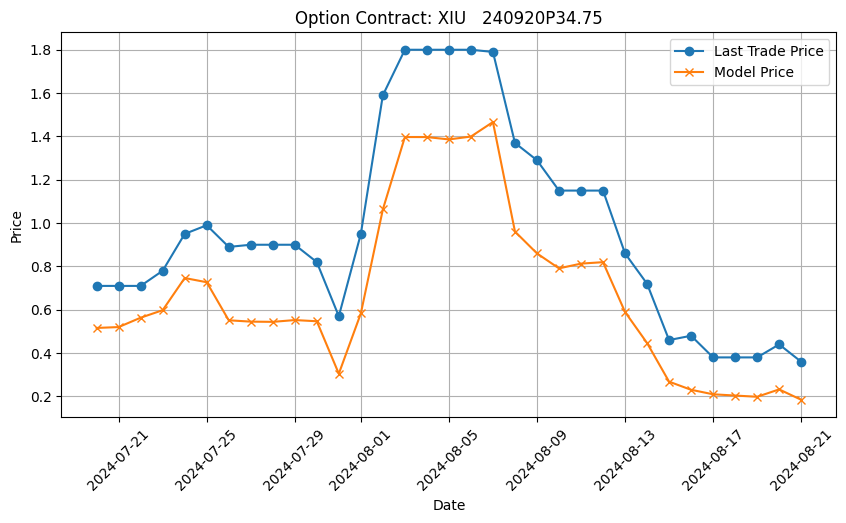

In [46]:
import matplotlib.pyplot as plt

# Choose a contract to plot
contract = "XIU   240920P34.75"  # Replace with an actual contract symbol from your data
df_contract = puts_monthly[puts_monthly["contract_symbol"] == contract].sort_values("query_date")

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(df_contract.index, df_contract["last_trade_price"], label="Last Trade Price", marker="o")
plt.plot(df_contract.index, df_contract["model_price"], label="Model Price", marker="x")

# Formatting
plt.xlabel("Date")
plt.ylabel("Price")
plt.title(f"Option Contract: {contract}")
plt.legend()
plt.grid()
plt.xticks(rotation=45)

plt.show()

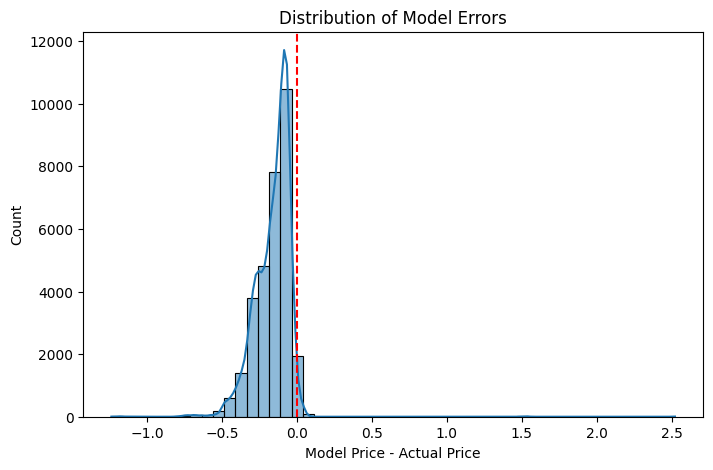

In [58]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(puts_monthly["model_price"] - puts_monthly["last_trade_price"], bins=50, kde=True)

plt.xlabel("Model Price - Actual Price")
plt.ylabel("Count")
plt.title("Distribution of Model Errors")
plt.axvline(0, color="red", linestyle="--")  # Perfect prediction line
plt.show()

In [59]:
puts["dte"].value_counts()

dte
11     3871
4      3856
18     3666
39     3536
25     3503
       ... 
41       17
564      15
450      13
48       13
449      13
Name: count, Length: 810, dtype: int64